# Solar Power Generation


## Part 1: Exploratory Data Analysis
## 1. Imports and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb


# Set plot style
plt.style.use('ggplot')
sns.set_palette('rocket')

%matplotlib inline

## 2. Load Data

In [11]:
gen_df = pd.read_csv('data/Plant_1_Generation_Data.csv')
sensor_df = pd.read_csv('data/Plant_1_Weather_Sensor_Data.csv')

# Parse dates
# Note: The format in the CSV appears to be dd-mm-yyyy hh:mm
gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'])
sensor_df['DATE_TIME'] = pd.to_datetime(sensor_df['DATE_TIME'])

print("Generation Data Shape:", gen_df.shape)
print("Sensor Data Shape:", sensor_df.shape)

Generation Data Shape: (68778, 7)
Sensor Data Shape: (3182, 6)


C:\conda_tmp\ipykernel_1884\1944104708.py:6: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'])


## 3. Data Inspection & Cleaning

In [19]:
display(gen_df.head())
display(sensor_df.head())

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [20]:
# Check for missing values
print("Missing in Gen:", gen_df.isnull().sum().sum())
print("Missing in Sensor:", sensor_df.isnull().sum().sum())

Missing in Gen: 0
Missing in Sensor: 0


## 4. Merging Data
We join the Weather data to the Generation data on `DATE_TIME`.
Since generation is per-inverter and weather is per-plant, the weather data will be repeated for each inverter at the same timestamp.

In [21]:
df = pd.merge(gen_df, sensor_df, on='DATE_TIME', how='left')
print("Merged Shape:", df.shape)
df.head()

Merged Shape: (68778, 12)


,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [ ]:
# Drop redundant columns if any (Plant_ID check)
df = df.drop(columns=['PLANT_ID_y'])
df = df.rename(columns={'PLANT_ID_x': 'PLANT_ID', 'SOURCE_KEY_x': 'INVERTER_ID', 'SOURCE_KEY_y': 'SENSOR_ID'})

df.head()

,DATE_TIME,PLANT_ID,INVERTER_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SENSOR_ID,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [41]:
# Drop Missing
df = df.dropna()
print("Final Shape:", df.shape)

Final Shape: (68774, 15)


## 5. Visual Analysis

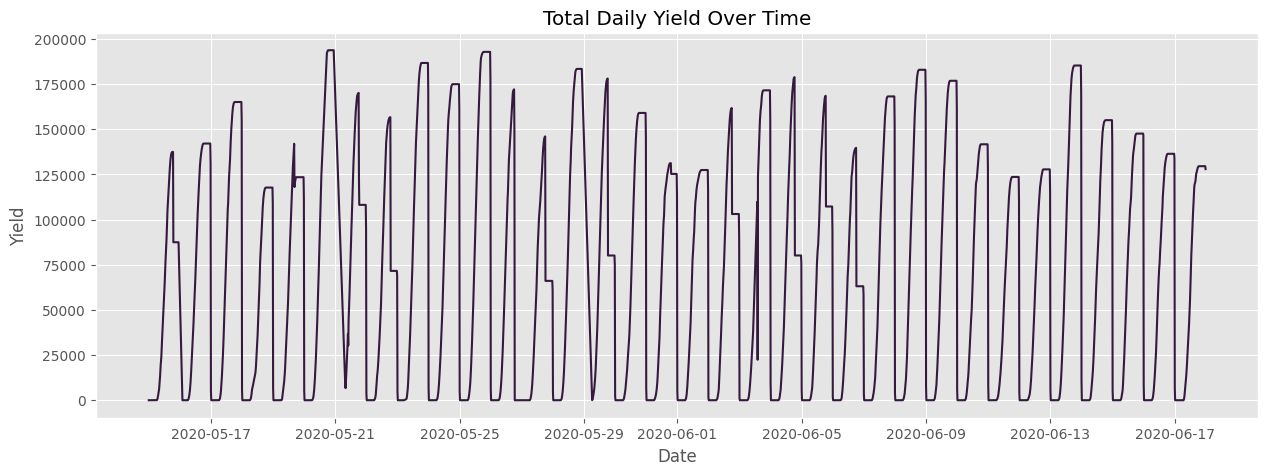

In [23]:
# 5.1 Total Daily Yield over time
daily_gen = df.groupby('DATE_TIME')['DAILY_YIELD'].sum()

plt.figure(figsize=(15, 5))
plt.plot(daily_gen.index, daily_gen.values)
plt.title('Total Daily Yield Over Time')
plt.ylabel('Yield')
plt.xlabel('Date')
plt.show()

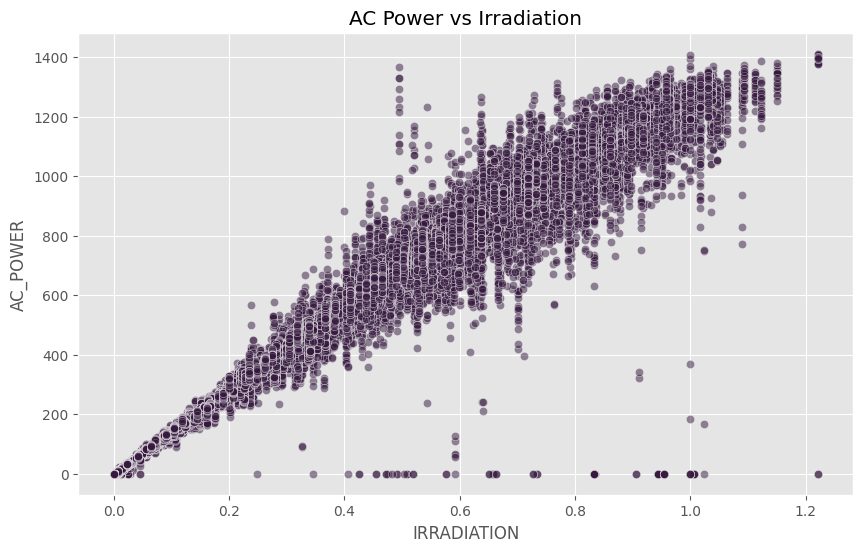

In [24]:
# 5.2 AC Power vs Irradiation
# Irradiation is the primary driver of solar power.

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='IRRADIATION', y='AC_POWER', alpha=0.5)
plt.title('AC Power vs Irradiation')
plt.show()

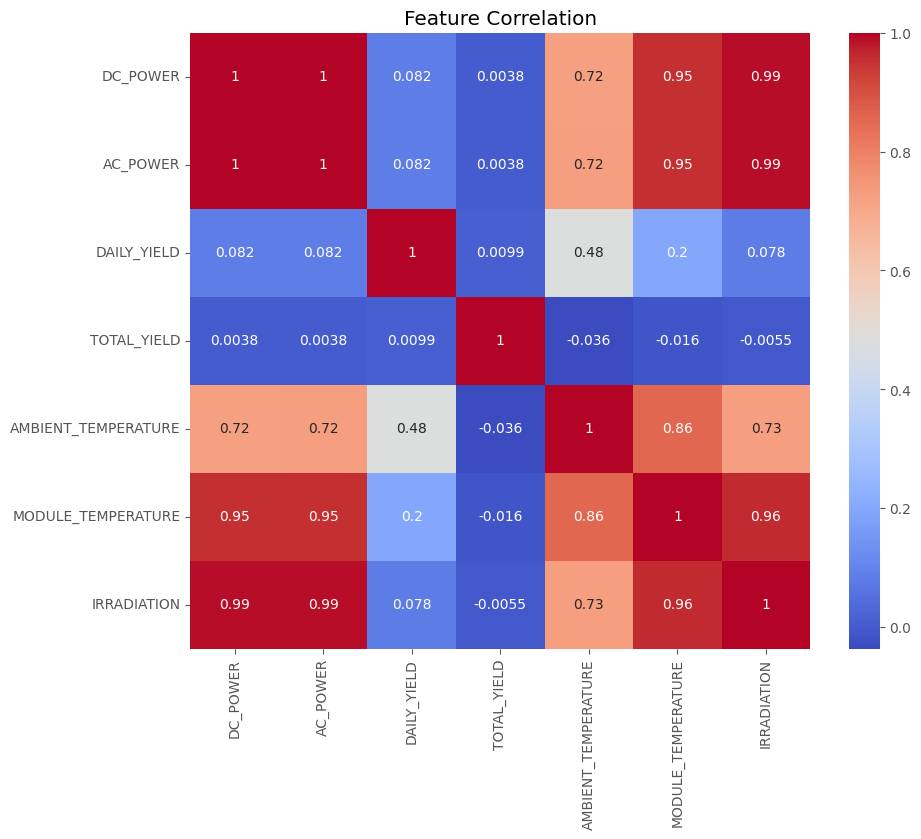

In [25]:
# 5.3 Correlation Heatmap
corr = df[['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

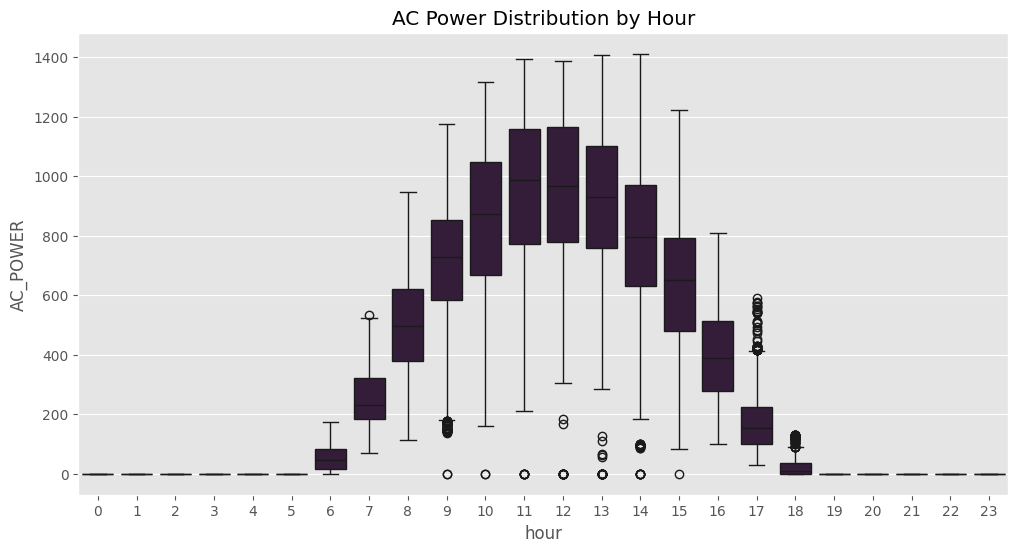

In [26]:
df['hour'] = df['DATE_TIME'].dt.hour

# Boxplot of AC Power by Hour
plt.figure(figsize=(12, 6))
sns.boxplot(x='hour', y='AC_POWER', data=df)
plt.title('AC Power Distribution by Hour')
plt.show()

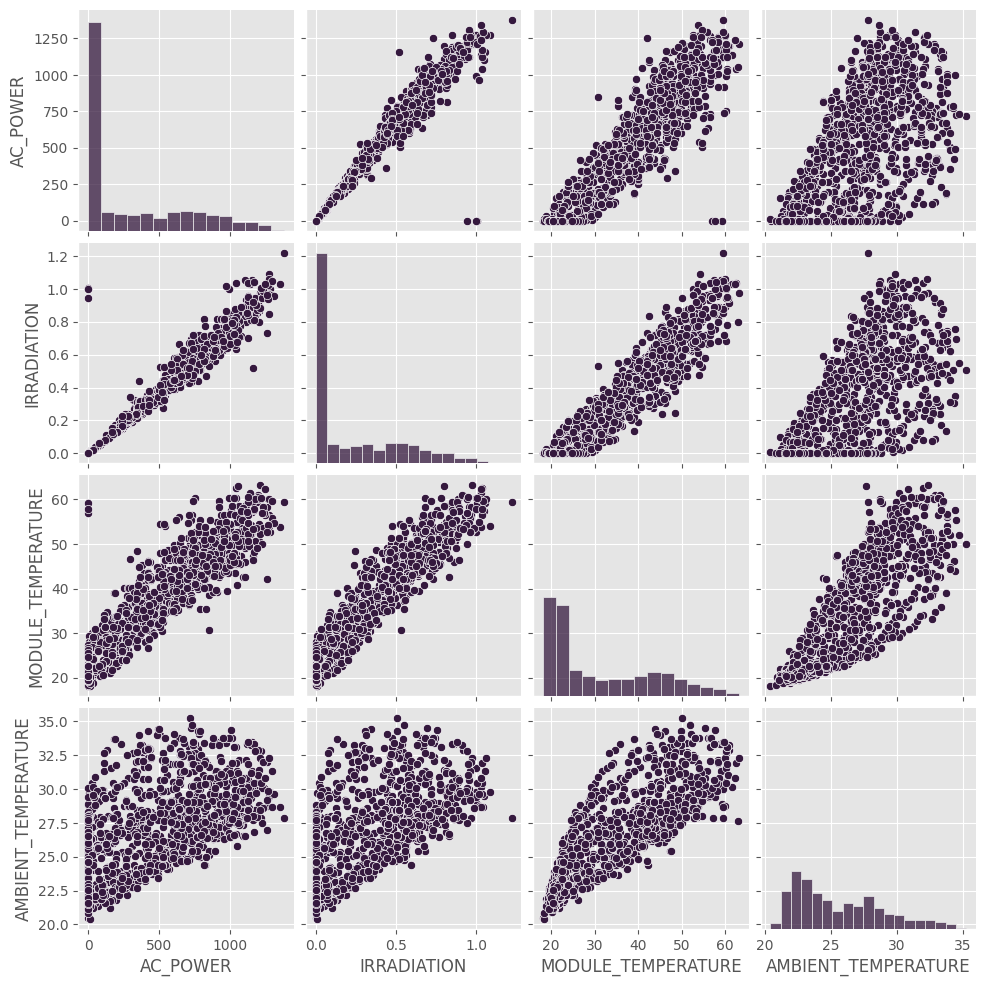

In [ ]:
# Pairplot for Key Metrics
# Sub-sample to speed up plotting since dataset is large
sample_df = df.sample(n=2000, random_state=42)
sns.pairplot(sample_df[['AC_POWER', 'IRRADIATION', 'MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE']])
plt.show()

## 6. Feature Importance (Random Forest)

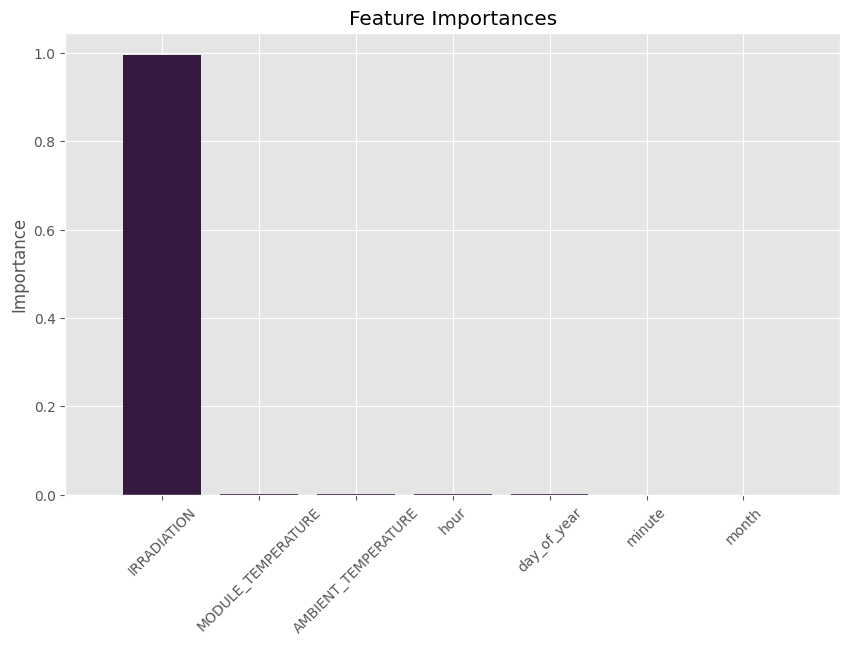

In [39]:
# Prepare Data for Feature Importance
df['minute'] = df['DATE_TIME'].dt.minute
features = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'hour', 'minute', 'month', 'day_of_year']
target = 'AC_POWER'

X_imp = df[features]
y_imp = df[target]

# Fit Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_imp, y_imp)

# Get Importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_imp.shape[1]), importances[indices], align="center")
plt.xticks(range(X_imp.shape[1]), [features[i] for i in indices], rotation=45)
plt.xlim([-1, X_imp.shape[1]])
plt.ylabel('Importance')
plt.show()

## Part 2: Modeling and Evaluation

We will compare multiple models:
1. Linear Regression (Baseline)
2. Random Forest Regressor
3. XGBoost Regressor (Gradient Boosting)
4. Deep Neural Network (Keras/TensorFlow)

## 1. Feature Engineering

In [43]:
# Extract Time Features
df['hour'] = df['DATE_TIME'].dt.hour
df['minute'] = df['DATE_TIME'].dt.minute
df['month'] = df['DATE_TIME'].dt.month
df['day_of_year'] = df['DATE_TIME'].dt.dayofyear

# Select Features and Target
features = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'hour', 'minute', 'month', 'day_of_year']
target = 'AC_POWER'

X = df[features]
y = df[target]

# Train/Test Split
# We use a standard split here. For strict time-series forecasting, we should split by date.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Important for DNN)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2. Modeling: Base Models

In [52]:
results_list = []
trained_models = {}

# 2.1 Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
preds_lr = lr.predict(X_test_scaled)
rmse_lr = np.sqrt(mean_squared_error(y_test, preds_lr))
r2_lr = r2_score(y_test, preds_lr)
results_list.append({'Model': 'Linear Regression', 'Type': 'Base', 'RMSE': rmse_lr, 'R2': r2_lr})
trained_models['Linear Regression'] = lr
print(f"Linear Regression - RMSE: {rmse_lr:.4f}kW, R2: {r2_lr:.4f}")

Linear Regression - RMSE: 55.3639kW, R2: 0.9801


In [54]:
# 2.2 Random Forest (Base)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, preds_rf))
r2_rf = r2_score(y_test, preds_rf)
results_list.append({'Model': 'Random Forest', 'Type': 'Base', 'RMSE': rmse_rf, 'R2': r2_rf})
trained_models['Random Forest'] = rf
print(f"Random Forest (Base) - RMSE: {rmse_rf:.2f}kW, R2: {r2_rf:.4f}")

Random Forest (Base) - RMSE: 45.67kW, R2: 0.9865


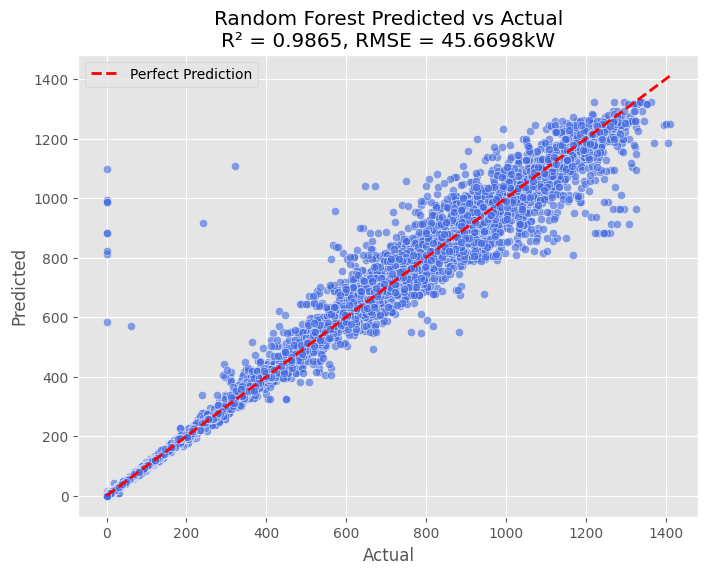

In [55]:
# Scatter plot of actual vs predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=preds_rf, alpha=0.6, color="royalblue")

# Plot the perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label="Perfect Prediction")

# Add labels and title
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Random Forest Predicted vs Actual\nR² = {r2_rf:.4f}, RMSE = {rmse_rf:.4f}kW")
plt.legend()
plt.grid(True)
plt.show()


In [56]:
# 2.3 XGBoost (Base)

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
preds_xgb = xgb_model.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, preds_xgb))
r2_xgb = r2_score(y_test, preds_xgb)
results_list.append({'Model': 'XGBoost', 'Type': 'Base', 'RMSE': rmse_xgb, 'R2': r2_xgb})
trained_models['XGBoost'] = xgb_model
print(f"XGBoost (Base) - RMSE: {rmse_xgb:.2f}kW, R2: {r2_xgb:.4f}")


XGBoost (Base) - RMSE: 45.97kW, R2: 0.9863


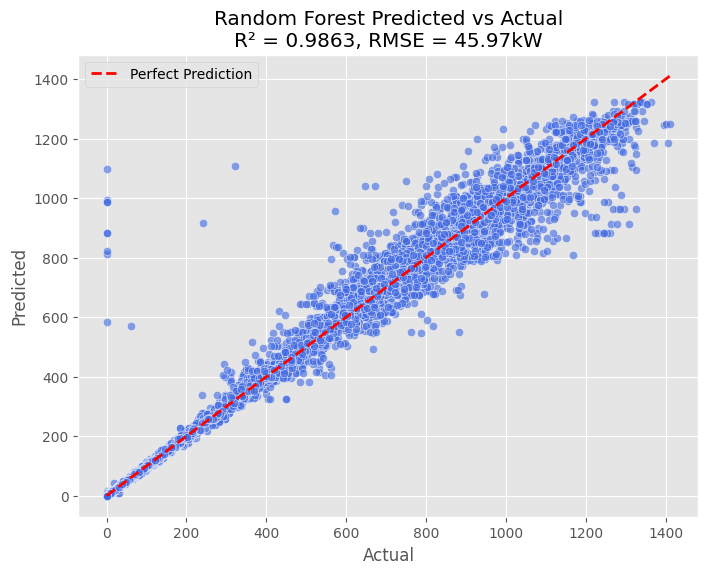

In [57]:
# Scatter plot of actual vs predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=preds_rf, alpha=0.6, color="royalblue")

# Plot the perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label="Perfect Prediction")

# Add labels and title
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Random Forest Predicted vs Actual\nR² = {r2_xgb:.4f}, RMSE = {rmse_xgb:.2f}kW")
plt.legend()
plt.grid(True)
plt.show()


## 3. Hyperparameter Tuning

In [61]:
# 3.1 Tuned Random Forest (Grid Search)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_grid_rf, cv=3, scoring='neg_root_mean_squared_error')
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
preds_rf_tuned = best_rf.predict(X_test)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, preds_rf_tuned))
r2_rf_tuned = r2_score(y_test, preds_rf_tuned)

results_list.append({'Model': 'Random Forest (Tuned)', 'Type': 'Tuned', 'RMSE': rmse_rf_tuned, 'R2': r2_rf_tuned})
trained_models['Random Forest (Tuned)'] = best_rf
print(f"Best RF Params: {grid_rf.best_params_}")
print(f"Random Forest (Tuned) - RMSE: {rmse_rf_tuned:.4f}kW, R2: {r2_rf_tuned:.4f}")

Best RF Params: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}
Random Forest (Tuned) - RMSE: 45.6368kW, R2: 0.9865


In [60]:
# 5.2 Tuned XGBoost

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 6]
}

grid_xgb = GridSearchCV(xgb.XGBRegressor(random_state=42), param_grid_xgb, cv=3, scoring='neg_root_mean_squared_error')
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
preds_xgb_tuned = best_xgb.predict(X_test)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, preds_xgb_tuned))
r2_xgb_tuned = r2_score(y_test, preds_xgb_tuned)

results_list.append({'Model': 'XGBoost (Tuned)', 'Type': 'Tuned', 'RMSE': rmse_xgb_tuned, 'R2': r2_xgb_tuned})
trained_models['XGBoost (Tuned)'] = best_xgb
print(f"Best XGB Params: {grid_xgb.best_params_}")
print(f"XGBoost (Tuned) - RMSE: {rmse_xgb_tuned:.4f}kW, R2: {r2_xgb_tuned:.4f}")

Best XGB Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
XGBoost (Tuned) - RMSE: 45.6298kW, R2: 0.9865


## 4. NN Variations

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Function to build and evaluate DNN models
def build_and_evaluate_dnn(name, layers_config, epochs=50):
    model = Sequential()
    model.add(Dense(layers_config[0]['units'], activation='relu', input_shape=(X_train_scaled.shape[1],)))
    if 'dropout' in layers_config[0]:
        model.add(Dropout(layers_config[0]['dropout']))
    
    for layer in layers_config[1:]:
        model.add(Dense(layer['units'], activation='relu'))
        if 'dropout' in layer:
            model.add(Dropout(layer['dropout']))
    
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse', metrics=['mse'])
    
    # Train with validation split
    history = model.fit(X_train_scaled, y_train, 
                        epochs=epochs, batch_size=32, 
                        validation_split=0.2, verbose=0)
    
    preds = model.predict(X_test_scaled).flatten()
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    print(f"{name} - RMSE: {rmse:.2f}kW, R2: {r2:.4f}")
    return model, history, preds, rmse, r2


In [62]:
# function to plot results
def plot_results(name, history, y_test, preds, r2, rmse):
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Loss curve
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f"{name} - Loss Curve")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("MSE Loss")
    axes[0].legend()

    # R² scatter plot
    sns.scatterplot(x=y_test, y=preds, alpha=0.6, color="royalblue", ax=axes[1])
    axes[1].plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()],
                 'r--', lw=2, label="Perfect Prediction")
    axes[1].set_title(f"{name}\nR²={r2:.4f}, RMSE={rmse:.2f}kW")
    axes[1].set_xlabel("Actual")
    axes[1].set_ylabel("Predicted")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


c:\Users\Hafeez Bello\.virtualenvs\Capstone_Project_2-Vn0U6Iwe\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
DNN (Base) - RMSE: 54.88kW, R2: 0.9805


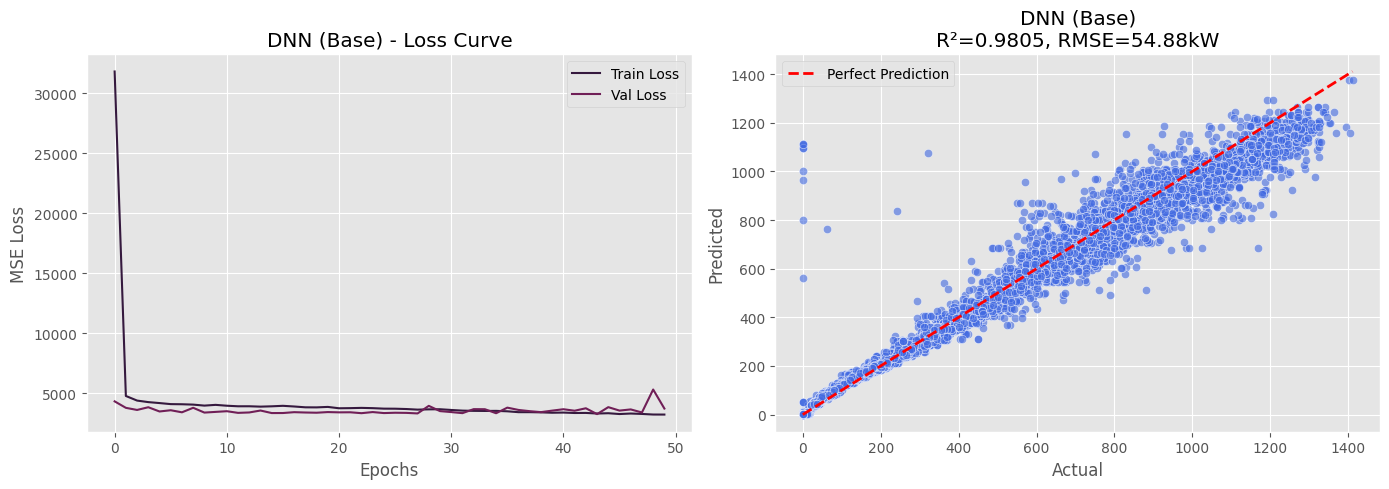

In [63]:
# 4.1 Base DNN
model1, history1, preds1, rmse1, r2_1 = build_and_evaluate_dnn(
    "DNN (Base)", [
        {'units': 128, 'dropout': 0.2},
        {'units': 64, 'dropout': 0.1},
        {'units': 32}
    ]
)
plot_results("DNN (Base)", history1, y_test, preds1, r2_1, rmse1)


c:\Users\Hafeez Bello\.virtualenvs\Capstone_Project_2-Vn0U6Iwe\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
DNN (Deep) - RMSE: 64.64kW, R2: 0.9729


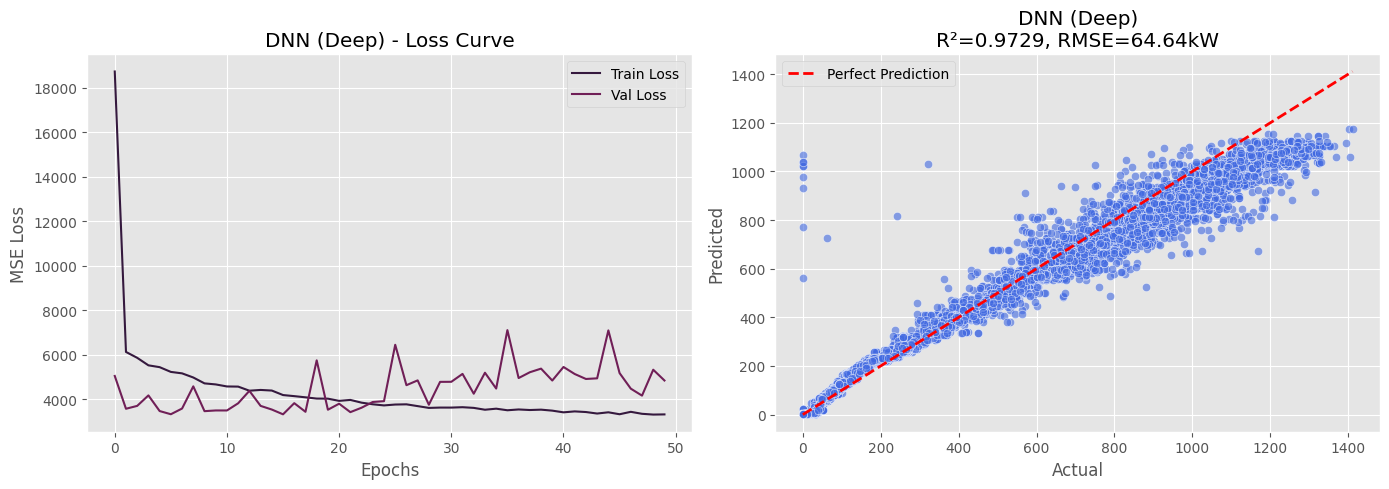

In [64]:
# 4.2 Deep DNN
model2, history2, preds2, rmse2, r2_2 = build_and_evaluate_dnn(
    "DNN (Deep)", [
        {'units': 128, 'dropout': 0.2},
        {'units': 128, 'dropout': 0.2},
        {'units': 64, 'dropout': 0.1},
        {'units': 64, 'dropout': 0.1},
        {'units': 32}
    ]
)
plot_results("DNN (Deep)", history2, y_test, preds2, r2_2, rmse2)


c:\Users\Hafeez Bello\.virtualenvs\Capstone_Project_2-Vn0U6Iwe\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
DNN (No Dropout) - RMSE: 50.69kW, R2: 0.9834


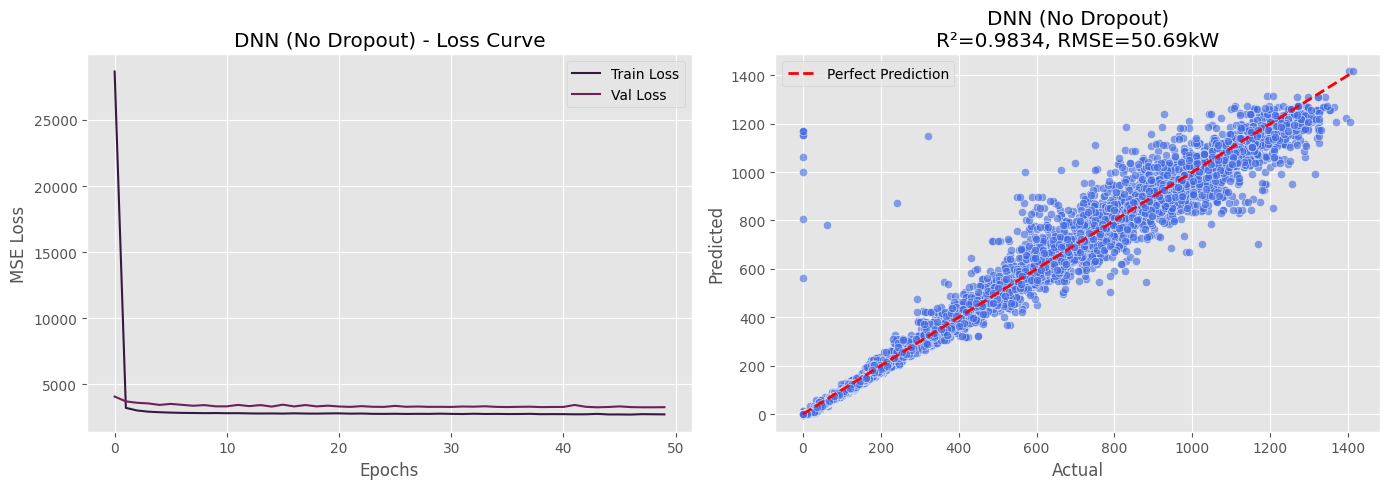

In [65]:
# 4.3 DNN (No Dropout)
model3, history3, preds3, rmse3, r2_3 = build_and_evaluate_dnn(
    "DNN (No Dropout)", [
        {'units': 128},
        {'units': 64},
        {'units': 32}
    ]
)
plot_results("DNN (No Dropout)", history3, y_test, preds3, r2_3, rmse3)


## 5. Final Comparison

,Model,Type,RMSE,R2
4,XGBoost (Tuned),Tuned,45.629751,0.986507
5,XGBoost (Tuned),Tuned,45.629751,0.986507
6,Random Forest (Tuned),Tuned,45.636815,0.986503
1,Random Forest,Base,45.669776,0.986483
2,Random Forest,Base,45.669776,0.986483
3,XGBoost,Base,45.968731,0.986305
0,Linear Regression,Base,55.363914,0.980136


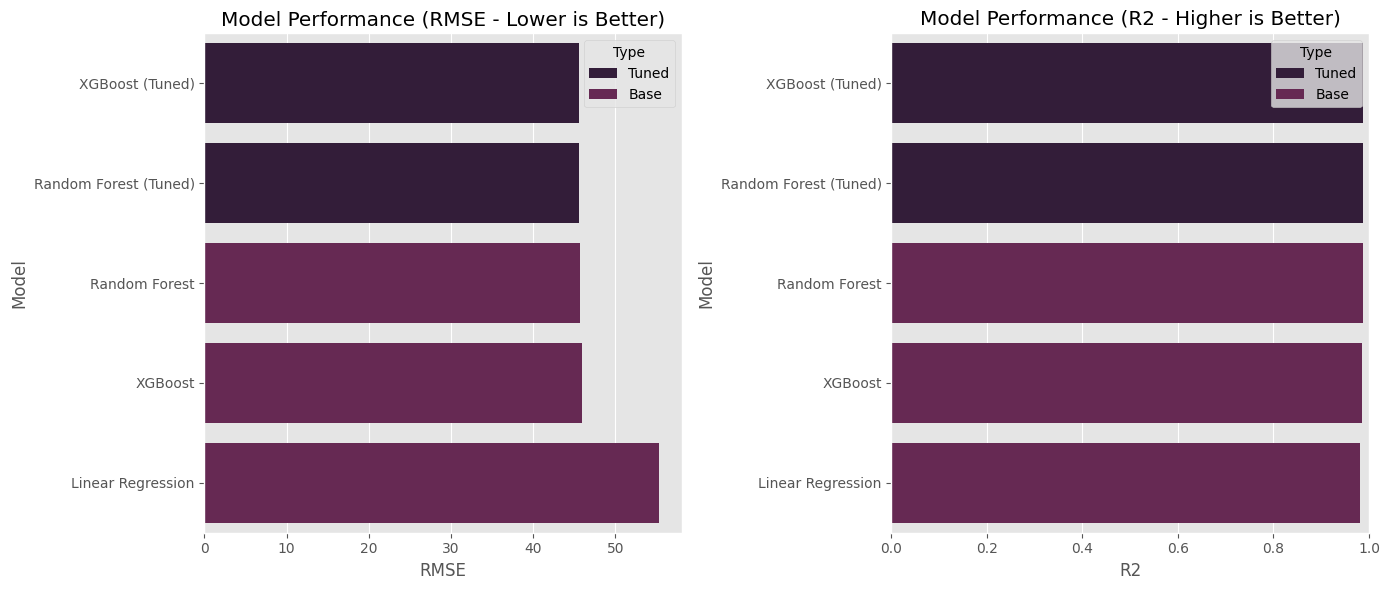

In [66]:
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='R2', ascending=False)

display(results_df)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='RMSE', y='Model', hue='Type', data=results_df)
plt.title('Model Performance (RMSE - Lower is Better)')

plt.subplot(1, 2, 2)
sns.barplot(x='R2', y='Model', hue='Type', data=results_df)
plt.title('Model Performance (R2 - Higher is Better)')
plt.xlim(0, 1.0)

plt.tight_layout()
plt.show()

## Save Best Model

In [67]:
# Identify best model
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R2']
print(f"Best Model: {best_model_name} (R2: {best_r2:.4f})")

best_model = trained_models[best_model_name]

# Save Scaler (Always needed for preprocessing inputs)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved to 'scaler.pkl'")

# Save Model logic
if 'DNN' in best_model_name:
    # Keras Model
    best_model.save('best_model.h5')
    print(f"DNN Model saved to 'best_model.h5'")
else:
    # Sklearn/XGBoost Model
    with open('best_model.pkl', 'wb') as f:
        pickle.dump(best_model, f)
    print(f"Model saved to 'best_model.pkl'")

Best Model: XGBoost (Tuned) (R2: 0.9865)
Scaler saved to 'scaler.pkl'
Model saved to 'best_model.pkl'
